# 스팸 분류 - 데이터 탐색(EDA) & 전처리 시각화

이 노트북은 학습 전에 **데이터와 전처리 과정을 눈으로 확인**하기 위한 것이다.

1. 데이터 로드 & 개요
2. 클래스/언어 분포
3. 텍스트 길이 분포 (→ MAX_LEN 근거)
4. 전처리 과정 단계별 시연 (글자 단위, URL/숫자 토큰)
5. 어휘사전 구축
6. 스팸 vs 정상 특징 문자 비교
7. 인코딩된 시퀀스 예시
8. (선택) 학습된 모델 예측 & 혼동행렬

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 프로젝트 루트 탐색 (data 폴더가 있는 상위 디렉터리)
ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'data'
print('프로젝트 루트:', ROOT)

# 한글 폰트 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 4)

프로젝트 루트: c:\Users\Win11Pro\Documents\과제\spam_detector


## 1. 데이터 로드 & 개요

In [2]:
df = pd.read_csv(DATA / 'spam.csv')
print('총 건수:', len(df))
print('컬럼:', list(df.columns))
display(df.head())
print('\n언어×클래스 분포:')
print(df.groupby(['lang', 'label']).size())

총 건수: 4772
컬럼: ['label', 'text', 'lang']


,label,text,lang
0,ham,Subject: 2 nd interview schedule for liz bella...,en
1,ham,Subject: unify / sitara enhancements i am comp...,en
2,spam,Subject: viagra soft tabs viagra soft tabs is ...,en
3,ham,"Subject: hpl nom for january 24 , 2001 ( see a...",en
4,ham,Subject: spot purchases - 04 / 01 the followin...,en



언어×클래스 분포:
lang  label
en    ham      1200
      spam     1200
ko    ham      1186
      spam     1186
dtype: int64


## 2. 클래스 / 언어 분포 시각화

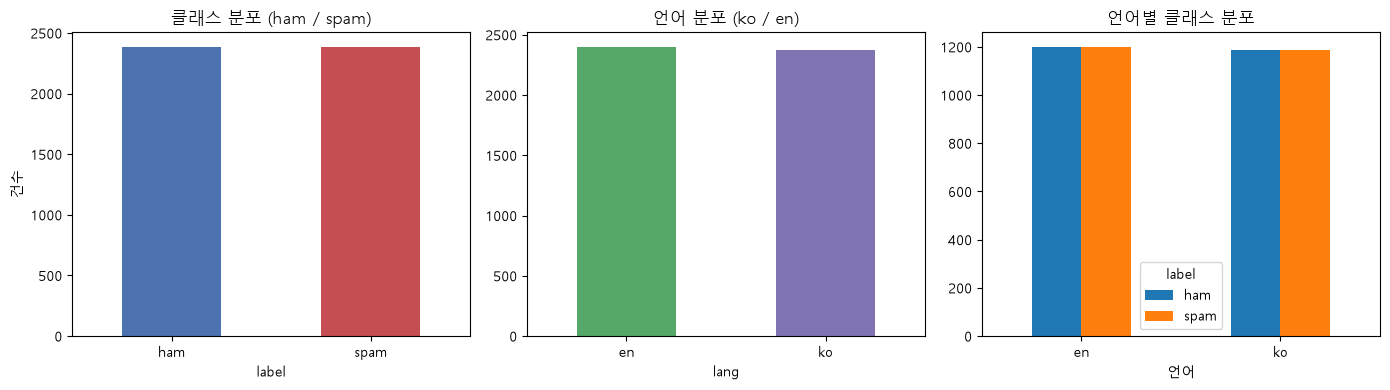

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title('클래스 분포 (ham / spam)')
axes[0].set_ylabel('건수')

df['lang'].value_counts().plot(kind='bar', ax=axes[1], color=['#55A868', '#8172B3'])
axes[1].set_title('언어 분포 (ko / en)')

ct = df.groupby(['lang', 'label']).size().unstack()
ct.plot(kind='bar', ax=axes[2])
axes[2].set_title('언어별 클래스 분포')
axes[2].set_xlabel('언어')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 3. 텍스트 길이 분포 (→ MAX_LEN 근거)

글자 단위 토큰화를 쓰므로 **글자 수** 분포를 본다. 대부분을 포괄하는 지점을 MAX_LEN으로 잡는다.

             mean    50%      max
lang                             
en    1091.918333  545.5  21748.0
ko     113.246627   60.0    908.0


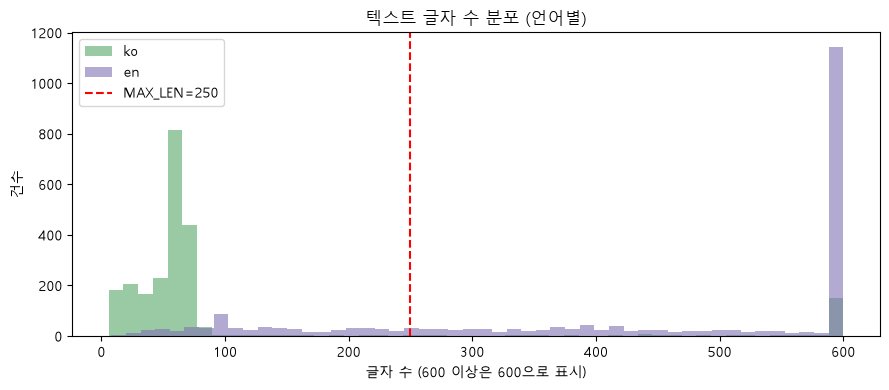

In [4]:
df['len'] = df['text'].str.len()
print(df.groupby('lang')['len'].describe()[['mean', '50%', 'max']])

fig, ax = plt.subplots(figsize=(9, 4))
for lang, color in [('ko', '#55A868'), ('en', '#8172B3')]:
    ax.hist(df[df.lang == lang]['len'].clip(upper=600), bins=50,
            alpha=0.6, label=lang, color=color)
ax.axvline(250, color='red', linestyle='--', label='MAX_LEN=250')
ax.set_title('텍스트 글자 수 분포 (언어별)')
ax.set_xlabel('글자 수 (600 이상은 600으로 표시)'); ax.set_ylabel('건수')
ax.legend(); plt.tight_layout(); plt.show()

## 4. 전처리 과정 단계별 시연

`clean_text()`는 (1) 소문자화 (2) URL→`<url>` (3) 숫자→`<num>` (4) 글자 단위 분해 를 수행한다.

In [5]:
from src.preprocessing import clean_text, build_vocab, encode

samples = [
    '(광고) 저금리 대출 1억 지금 신청 http://bit.ly/xz39',
    '내일 오후 2시 회의 참석 부탁드립니다',
    'Subject: free money click now !!!',
]
for s in samples:
    toks = clean_text(s)
    print('원문 :', s)
    print('토큰 :', toks[:25], '...' if len(toks) > 25 else '')
    print('토큰수:', len(toks), '\n')

원문 : (광고) 저금리 대출 1억 지금 신청 http://bit.ly/xz39
토큰 : ['(', '광', '고', ')', '저', '금', '리', '대', '출', '<num>', '억', '지', '금', '신', '청', '<url>'] 
토큰수: 16 

원문 : 내일 오후 2시 회의 참석 부탁드립니다
토큰 : ['내', '일', '오', '후', '<num>', '시', '회', '의', '참', '석', '부', '탁', '드', '립', '니', '다'] 
토큰수: 16 

원문 : Subject: free money click now !!!
토큰 : ['s', 'u', 'b', 'j', 'e', 'c', 't', ':', 'f', 'r', 'e', 'e', 'm', 'o', 'n', 'e', 'y', 'c', 'l', 'i', 'c', 'k', 'n', 'o', 'w'] ...
토큰수: 28 



## 5. 어휘사전(vocab) 구축

어휘사전 크기: 865
특수 토큰: {'<pad>': 0, '<unk>': 1}


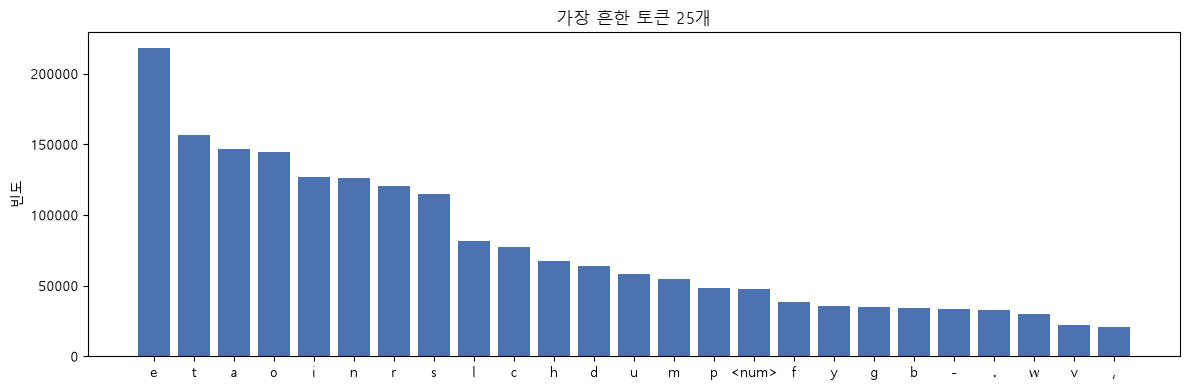

In [6]:
vocab = build_vocab(df['text'].tolist())
print('어휘사전 크기:', len(vocab))
print('특수 토큰:', {k: vocab[k] for k in list(vocab)[:2]})

# 전체 토큰 빈도 상위 25개 (특수문자 토큰 포함)
cnt = Counter()
for t in df['text']:
    cnt.update(clean_text(t))
top = cnt.most_common(25)
labels, values = zip(*top)
plt.figure(figsize=(12, 4))
plt.bar(range(len(labels)), values, color='#4C72B0')
plt.xticks(range(len(labels)), labels, rotation=0)
plt.title('가장 흔한 토큰 25개'); plt.ylabel('빈도')
plt.tight_layout(); plt.show()

## 6. 스팸 vs 정상 - 특징적인 토큰 비교

각 클래스에서 상대적으로 더 자주 등장하는 토큰을 본다 (스팸성 신호 확인).

In [7]:
def token_counter(texts):
    c = Counter()
    for t in texts:
        c.update(set(clean_text(t)))   # 문서 단위 등장(중복 제거)
    return c

spam_c = token_counter(df[df.label == 'spam']['text'])
ham_c = token_counter(df[df.label == 'ham']['text'])
n_spam = (df.label == 'spam').sum(); n_ham = (df.label == 'ham').sum()

# 스팸 비율이 높은 토큰 (최소 등장 20회)
rows = []
for tok in set(spam_c) | set(ham_c):
    s = spam_c.get(tok, 0); h = ham_c.get(tok, 0)
    if s + h < 20:
        continue
    spam_ratio = (s / n_spam) / ((s / n_spam) + (h / n_ham) + 1e-9)
    rows.append((tok, spam_ratio, s, h))
top_spam = sorted(rows, key=lambda x: -x[1])[:15]
top_ham = sorted(rows, key=lambda x: x[1])[:15]
print('▶ 스팸 신호 토큰 TOP15:', [r[0] for r in top_spam])
print('▶ 정상 신호 토큰 TOP15:', [r[0] for r in top_ham])

▶ 스팸 신호 토큰 TOP15: ['값', '`', '핫', '딜', '^', '럴', '\\', '|', '암', '첫', '즉', '엄', '셨', '삼', '윤']
▶ 정상 신호 토큰 TOP15: ['①', '범', '될', '○', '☏', '걷', '또', '군', '▼', '캠', '③', '☎', '좌', '※', '팽']


## 7. 인코딩된 시퀀스 예시

토큰을 정수 인덱스로 바꾸고 고정 길이로 패딩한 결과 (LSTM 입력 형태).

In [8]:
ex = '(광고) 무료 상품 당첨 지금 클릭'
ids = encode(ex, vocab, max_len=30)
print('원문:', ex)
print('인덱스 시퀀스 (앞 30):')
print(ids)
print('\n0 = <pad> (뒤쪽 채움), 1 = <unk>')

원문: (광고) 무료 상품 당첨 지금 클릭
인덱스 시퀀스 (앞 30):
[32, 136, 82, 33, 138, 119, 73, 177, 191, 265, 44, 86, 382, 408, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

0 = <pad> (뒤쪽 채움), 1 = <unk>


## 8. (선택) 학습된 모델 예측 & 혼동행렬

`python src/train.py` 로 모델을 먼저 학습해야 실행된다. 데모 샘플로 예측을 시연한다.

데모 샘플 정확도: 1.000  (n=120)


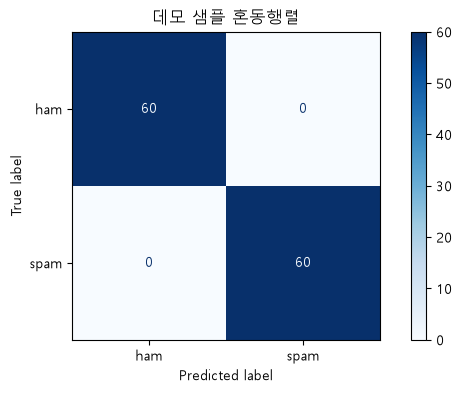

In [9]:
try:
    from src.predict import SpamPredictor
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    predictor = SpamPredictor()
    demo = pd.read_csv(DATA / 'demo_samples.csv')
    demo['pred'] = demo['text'].apply(lambda t: predictor.predict(t)[0])
    acc = (demo['pred'] == demo['label']).mean()
    print(f'데모 샘플 정확도: {acc:.3f}  (n={len(demo)})')

    cm = confusion_matrix(demo['label'], demo['pred'], labels=['ham', 'spam'])
    ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(cmap='Blues')
    plt.title('데모 샘플 혼동행렬'); plt.show()
except SystemExit as e:
    print('모델이 아직 없습니다. 먼저 python src/train.py 실행:', e)

In [10]:
# 임의의 문장으로 직접 테스트해보기
try:
    for t in ['안녕하세요 회의 자료 첨부합니다', '무료 코인 10배 수익 리딩방 입장']:
        label, prob = predictor.predict(t)
        print(f'[{label:4}] 스팸확률 {prob:.1%}  | {t}')
except NameError:
    print('predictor 가 없습니다 (위 셀 먼저 실행).')

[spam] 스팸확률 99.0%  | 안녕하세요 회의 자료 첨부합니다
[spam] 스팸확률 84.0%  | 무료 코인 10배 수익 리딩방 입장
